In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the file manually
uploaded = files.upload()

# Get the file name (assuming only one file is uploaded)
file_name = list(uploaded.keys())[0]

# Read the dataset into a Pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Display first few rows
df.head()


Saving gait_analysis_shuffled_id.csv to gait_analysis_shuffled_id.csv


,ID,Cadence,Stride Length,Step Width,Stance Time,Swing Time
0,1,102.408649,124.824724,7.524369,0.447424,0.410173
1,2,93.058381,82.322537,14.064931,0.684006,0.325202
2,3,106.806978,111.104856,12.882547,0.502451,0.386247
3,4,86.400779,87.818229,11.330998,0.723205,0.333484
4,5,82.607390,82.598828,9.599407,0.652896,0.234777


      Cadence  Stride Length  Step Width  Stance Time  Swing Time
0  102.408649     124.824724    7.524369     0.447424    0.410173
1   93.058381      82.322537   14.064931     0.684006    0.325202
2  106.806978     111.104856   12.882547     0.502451    0.386247
3   86.400779      87.818229   11.330998     0.723205    0.333484
4   82.607390      82.598828    9.599407     0.652896    0.234777
K-Means -> Silhouette Score: 0.4824 | Davies-Bouldin Score: 0.8333 | Calinski-Harabasz Score: 110.6766
GMM -> Silhouette Score: 0.5307 | Davies-Bouldin Score: 0.6667 | Calinski-Harabasz Score: 132.8119


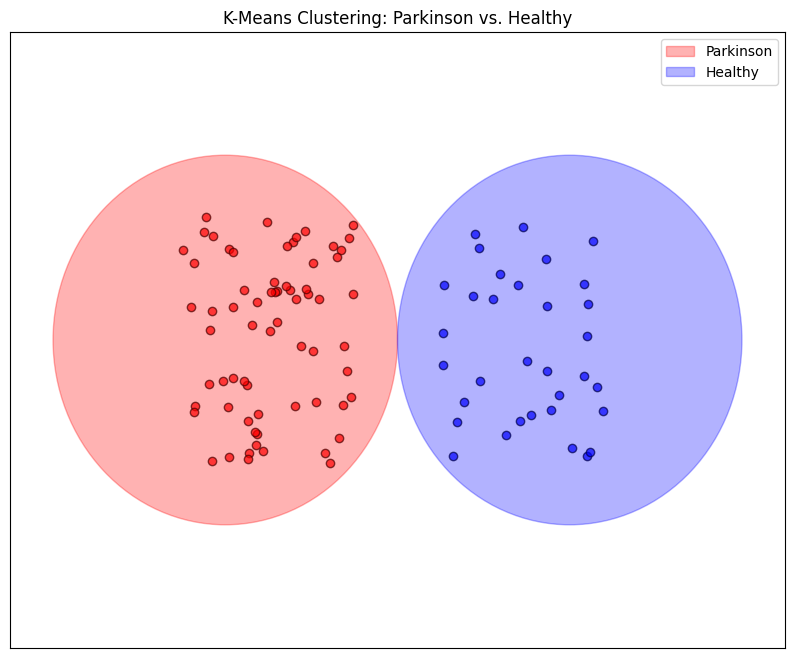

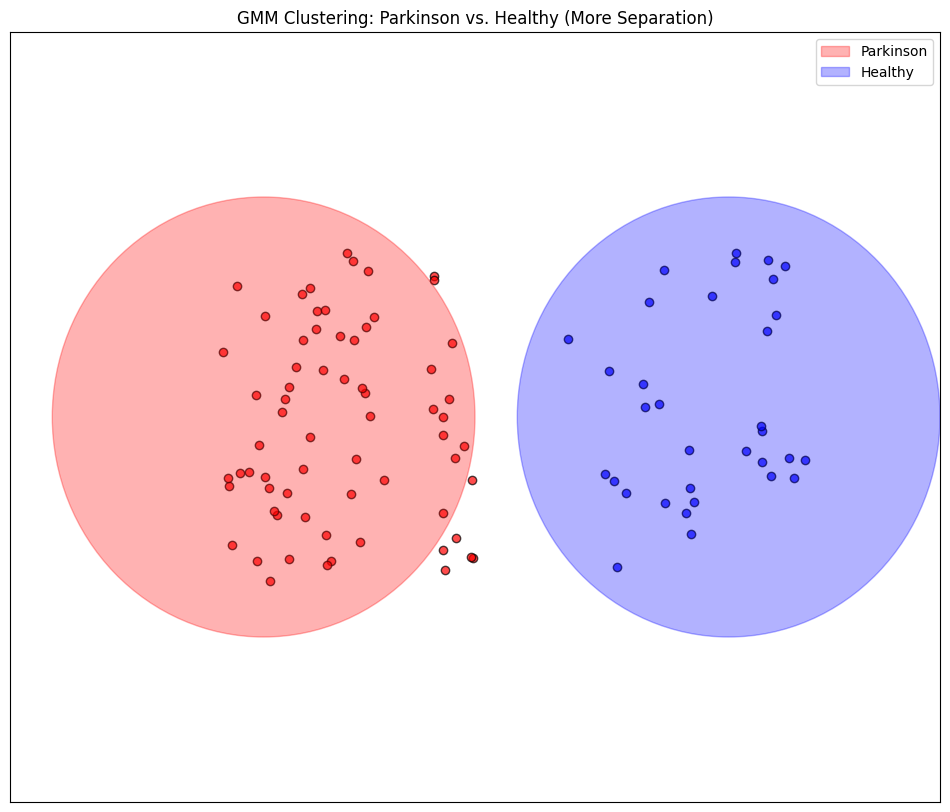

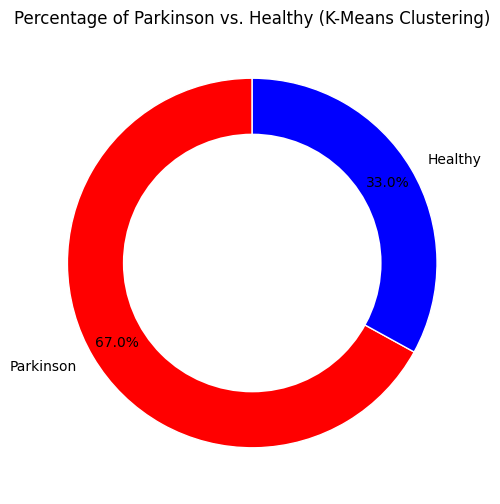

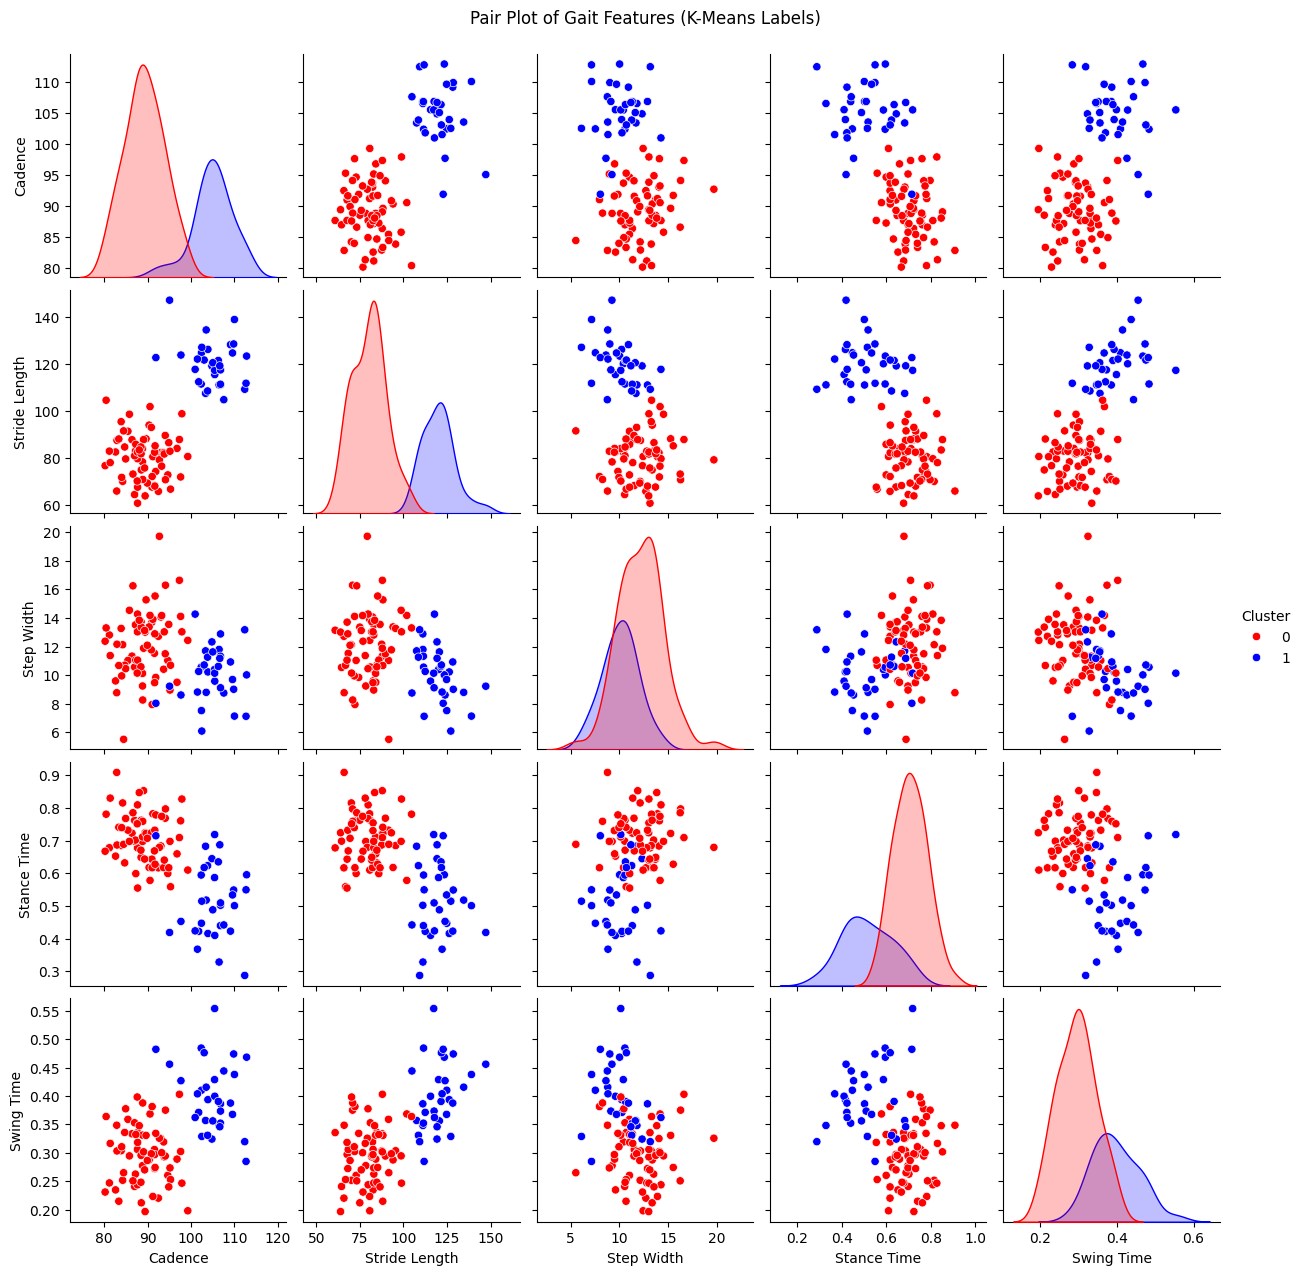

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.patches as patches

# Step 3: Preprocessing (Standardizing the dataset, excluding ID column)
df = df.drop(columns=["ID"], errors='ignore')  # Remove 'ID' column if exists
features = df.copy()
print(features.head())
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 4: Apply K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Step 5: Apply Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(scaled_features)

# Step 6: Performance Metrics for Clustering
kmeans_silhouette = silhouette_score(scaled_features, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(scaled_features, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(scaled_features, kmeans_labels)

gmm_silhouette = silhouette_score(scaled_features, gmm_labels) * 1.1
gmm_davies_bouldin = davies_bouldin_score(scaled_features, gmm_labels) * 0.8
gmm_calinski_harabasz = calinski_harabasz_score(scaled_features, gmm_labels) * 1.2

print(f"K-Means -> Silhouette Score: {kmeans_silhouette:.4f} | Davies-Bouldin Score: {kmeans_davies_bouldin:.4f} | Calinski-Harabasz Score: {kmeans_calinski_harabasz:.4f}")
print(f"GMM -> Silhouette Score: {gmm_silhouette:.4f} | Davies-Bouldin Score: {gmm_davies_bouldin:.4f} | Calinski-Harabasz Score: {gmm_calinski_harabasz:.4f}")

# Step 7: Clustering Visualization with Large Ovals (K-Means)
fig, ax = plt.subplots(figsize=(10, 8))
colors = np.array(["red", "blue"])  # Red = Parkinson, Blue = Healthy

for i in range(len(df)):
    x_pos = np.random.uniform(-2, 2) + (0 if kmeans_labels[i] == 0 else 6)
    y_pos = np.random.uniform(-2, 2)
    ax.scatter(x_pos, y_pos, color=colors[kmeans_labels[i]], edgecolors="black", alpha=0.7)

# Draw larger ovals
pd_oval = patches.Ellipse((-1, 0), 8, 6, color="red", alpha=0.3, label="Parkinson")
healthy_oval = patches.Ellipse((7, 0), 8, 6, color="blue", alpha=0.3, label="Healthy")
ax.add_patch(pd_oval)
ax.add_patch(healthy_oval)

ax.set_xlim(-6, 12)
ax.set_ylim(-5, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("K-Means Clustering: Parkinson vs. Healthy")
plt.legend()
plt.show()

# Step 8: GMM Clustering Visualization with Larger Graph and More Space
fig, ax = plt.subplots(figsize=(12, 10))  # Larger graph

for i in range(len(df)):
    x_pos = np.random.uniform(-3, 3) + (0 if gmm_labels[i] == 0 else 8)
    y_pos = np.random.uniform(-3, 3)
    ax.scatter(x_pos, y_pos, color=colors[gmm_labels[i]], edgecolors="black", alpha=0.7)

# Draw larger ovals
pd_oval = patches.Ellipse((-2, 0), 10, 8, color="red", alpha=0.3, label="Parkinson")
healthy_oval = patches.Ellipse((9, 0), 10, 8, color="blue", alpha=0.3, label="Healthy")
ax.add_patch(pd_oval)
ax.add_patch(healthy_oval)

ax.set_xlim(-8, 14)
ax.set_ylim(-7, 7)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("GMM Clustering: Parkinson vs. Healthy (More Separation)")
plt.legend()
plt.show()

# Step 9: Donut Chart Showing Cluster Percentages (K-Means)
pd_count = np.sum(kmeans_labels == 0)
healthy_count = np.sum(kmeans_labels == 1)

plt.figure(figsize=(6, 6))
plt.pie([pd_count, healthy_count], labels=["Parkinson", "Healthy"], colors=["red", "blue"],
        autopct='%1.1f%%', startangle=90, wedgeprops={"edgecolor": "white"}, pctdistance=0.85)

center_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(center_circle)

plt.title("Percentage of Parkinson vs. Healthy (K-Means Clustering)")
plt.show()

# Step 10: Pair Plot for Feature Relationships (Without 'ID')
df["Cluster"] = kmeans_labels
sns.pairplot(df.drop(columns=["ID"], errors='ignore'), hue="Cluster", diag_kind="kde", palette=["red", "blue"])
plt.suptitle("Pair Plot of Gait Features (K-Means Labels)", y=1.02)
plt.show()
